In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , mean_squared_error,mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)
df["Price"] = housing.target


In [4]:
X = df.iloc[:, :-1]   
y = df.iloc[:, -1]    

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
X = housing.data
y = housing.target

In [8]:
df.shape

(20640, 9)

In [9]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [11]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.corr(numeric_only=True)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [14]:
df.nunique()

MedInc        12928
HouseAge         52
AveRooms      19392
AveBedrms     14233
Population     3888
AveOccup      18841
Latitude        862
Longitude       844
Price          3842
dtype: int64

In [15]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [16]:
print(housing.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [17]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [18]:
housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

<function matplotlib.pyplot.show(close=None, block=None)>

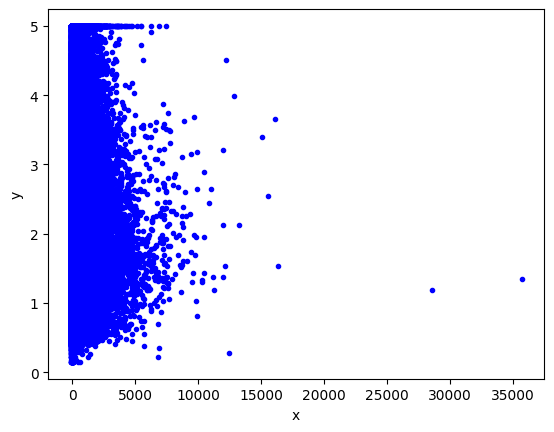

In [19]:
plt.plot(X,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
model = LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_train)
print("R2 score for training: ",r2_score(y_train,y_pred))

y_pred1=model.predict(X_test)
print("R2 score for testing: ",r2_score(y_test,y_pred1))

print("Mean absolute error for training: ",mean_absolute_error(y_train,y_pred))
print("Mean absolute error for testing: ",mean_absolute_error(y_test,y_pred1))

print("Mean squared error for training: ",mean_squared_error(y_train,y_pred))
print("Mean squared error for testing: ",mean_squared_error(y_test,y_pred1))


R2 score for training:  0.6068205998456939
R2 score for testing:  0.6013853272055164
Mean absolute error for training:  0.5303857028687304
Mean absolute error for testing:  0.5358292549658186
Mean squared error for training:  0.521993512908973
Mean squared error for testing:  0.5369436868086989


In [21]:
for i in range(10):
    pred = model.predict(X_test[i].reshape(1,-1))[0]

    print(
        f"Actual: {y_test[i]:.3f} | "
        f"Predicted: {pred:.3f} | "
        f"Error: {abs(y_test[i]-pred):.3f}"
    )

Actual: 2.787 | Predicted: 2.810 | Error: 0.023
Actual: 2.076 | Predicted: 1.253 | Error: 0.823
Actual: 0.967 | Predicted: 1.447 | Error: 0.480
Actual: 3.538 | Predicted: 2.484 | Error: 1.054
Actual: 3.905 | Predicted: 3.424 | Error: 0.481
Actual: 3.088 | Predicted: 2.662 | Error: 0.426
Actual: 2.813 | Predicted: 2.855 | Error: 0.042
Actual: 0.675 | Predicted: 1.644 | Error: 0.969
Actual: 0.990 | Predicted: 2.053 | Error: 1.063
Actual: 2.822 | Predicted: 2.237 | Error: 0.585


In [22]:
poly2 = PolynomialFeatures(degree=2,include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

poly2_model = LinearRegression()
poly2_model.fit(X_train_poly2,y_train)

x_pred = poly2_model.predict(X_train_poly2)
print("R2 Score in training:", r2_score(y_train, x_pred))

x_pred1 = poly2_model.predict(X_test_poly2)
print("R2 Score in test:", r2_score(y_test, x_pred1)) 


R2 Score in training: 0.6814638980284171
R2 Score in test: 0.6147331254077032


In [23]:
from sklearn.preprocessing import StandardScaler

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

scaler = StandardScaler()

X_train_poly3 = scaler.fit_transform(X_train_poly3)
X_test_poly3 = scaler.transform(X_test_poly3)
poly_model3 = LinearRegression()
poly_model3.fit(X_train_poly3, y_train)

z_pred = poly_model3.predict(X_train_poly3)
print("R2 Score in training:", r2_score(y_train, z_pred))

z_pred1 = poly_model3.predict(X_test_poly3)
print("R2 Score in test:", r2_score(y_test, z_pred1)) 

R2 Score in training: 0.7384802585753596
R2 Score in test: -1708.6221939901416


In [24]:
print(z_pred1[:10])
print(y_test[:10])

[2.78124795 1.23768439 1.12192896 3.18553443 3.4972714  2.64982543
 3.06159279 2.18663994 1.63210021 2.5393227 ]
[2.787 2.076 0.967 3.538 3.905 3.088 2.813 0.675 0.99  2.822]


In [25]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly2, y_train)

c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.46382e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Ridge()

In [26]:
y_train_ridge = ridge.predict(X_train_poly2)
y_test_ridge = ridge.predict(X_test_poly2)

In [27]:
print("Train R2 :", r2_score(y_train, y_train_ridge))
print("Test R2  :", r2_score(y_test, y_test_ridge))

print("Train MAE:", mean_absolute_error(y_train, y_train_ridge ))
print("Test MAE :", mean_absolute_error(y_test, y_test_ridge))

print("Train MSE:", mean_squared_error(y_train, y_train_ridge))
print("Test MSE :", mean_squared_error(y_test, y_test_ridge))

Train R2 : 0.6784865936150057
Test R2  : 0.618103535087072
Train MAE: 0.4667574495817084
Test MAE : 0.47249588147783994
Train MSE: 0.42684818273889263
Test MSE : 0.5144238530207816


In [28]:
for alpha in [0.01, 0.1, 1, 10, 100]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly2, y_train)

    train_r2 = r2_score(y_train, ridge.predict(X_train_poly2))
    test_r2 = r2_score(y_test, ridge.predict(X_test_poly2))

    print(f"Alpha={alpha:>5} | Train={train_r2:.4f} | Test={test_r2:.4f}")

Alpha= 0.01 | Train=0.6814 | Test=0.6211
Alpha=  0.1 | Train=0.6805 | Test=0.6293


Alpha=    1 | Train=0.6785 | Test=0.6181
Alpha=   10 | Train=0.6720 | Test=0.5714
Alpha=  100 | Train=0.6678 | Test=0.5679


c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.29306e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.00303e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.46382e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.70846e-18): result may not be accurate.
  return linalg.solve

In [38]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_poly2,y_train)

y_train_lasso = lasso.predict(X_train_poly2)
y_test_lasso = lasso.predict(X_test_poly2)

print("Train R2 :", r2_score(y_train, y_train_lasso))
print("Test R2  :", r2_score(y_test, y_test_lasso))

print("Train MAE:", mean_absolute_error(y_train, y_train_lasso))
print("Test MAE :", mean_absolute_error(y_test, y_test_lasso))

print("Train MSE:", mean_squared_error(y_train, y_train_lasso))
print("Test MSE :", mean_squared_error(y_test, y_test_lasso))

Train R2 : 0.6238397431422964
Test R2  : 0.6149054530923568
Train MAE: 0.5167457397916871
Test MAE : 0.5235341194554094
Train MSE: 0.4993985285516844
Test MSE : 0.5187317474716323


c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.295e+03, tolerance: 2.192e+00
  model = cd_fast.enet_coordinate_descent(


In [30]:
# Compare different alpha values
alphas = [0.001, 0.01, 0.1, 1.0, 10]

print("\n" + "="*60)
print("LASSO WITH DIFFERENT ALPHA VALUES")
print("="*60)
print(f"{'Alpha':<10} {'R² Score':<15} {'Features Used':<15}")
print("-"*60)

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_poly2, y_train)
    y_pred3 = lasso.predict(X_test_poly2)
    r2 = r2_score(y_test, y_pred3)
    n_features = np.sum(lasso.coef_ != 0)
    
    print(f"{alpha:<10.3f} {r2:<15.4f} {n_features}/{len(lasso.coef_)}")



LASSO WITH DIFFERENT ALPHA VALUES
Alpha      R² Score        Features Used  
------------------------------------------------------------


c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.789e+03, tolerance: 2.192e+00
  model = cd_fast.enet_coordinate_descent(


0.001      0.0282          41/44


c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.826e+03, tolerance: 2.192e+00
  model = cd_fast.enet_coordinate_descent(


0.010      -0.0600         35/44


c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.965e+03, tolerance: 2.192e+00
  model = cd_fast.enet_coordinate_descent(


0.100      0.2379          28/44


c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.295e+03, tolerance: 2.192e+00
  model = cd_fast.enet_coordinate_descent(


1.000      0.6149          18/44
10.000     0.5762          15/44


c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.437e+00, tolerance: 2.192e+00
  model = cd_fast.enet_coordinate_descent(
